---
title: "从大众点评数据到餐厅经营决策"
subtitle: "文本数据采集 · 清洗 · 词频分析 · 主题建模 · 情感分析 · 可视化"
author: "数据分析与经济决策"
date: today
format:
  html:
    toc: true
    toc-depth: 3
    toc-title: "目录"
    number-sections: true
    code-fold: true
    code-tools: true
    theme: cosmo
    highlight-style: github
jupyter: python3
---

# 爬虫+文本分析：从大众点评数据到餐厅经营决策

## 导言：为什么用餐厅评论做案例？

消费者在大众点评上留下的每一条评论，都是一条关于「体验」的数据。
一家餐厅一年可能积累数千条评论，人工阅读无法穷尽，但数据分析可以。

本章以大众点评餐厅评论为贯穿全程的素材，完整演示一条分析链条：

| Step | 环节 | 回答的问题 |
|------|------|-----------|
| 1 | 数据爬取 | 数据从哪里来？合规边界在哪里？ |
| 2 | 数据清洗 | 原始数据有哪些问题？如何处理？ |
| 3 | 词频与词云 | 消费者最常提到什么？ |
| 4 | 主题分析 | 评论涉及哪些议题？ |
| 5 | 情感分析 | 消费者对各议题的态度如何？ |
| 6 | 可视化与决策 | 分析结果如何服务于经营决策？ |

::: {.callout-important}
## 本章的学习方式：AI 辅助分析

本章不要求你记忆 Python 语法，也不要求你从零写代码。

**核心技能是：写清楚你想做什么，让 AI 生成代码，理解代码逻辑，根据需要修改。**

每个关键步骤前，你都会看到一个「💬 提示词参考」框，展示如何向 AI（如 Claude 或 ChatGPT）描述任务以获得可用代码。学会写好提示词，比背代码更有价值——因为语言在变，但描述问题的能力永远有用。
:::

---

## Step 1  数据爬取

> *数据从哪里来？怎样合规地获取？*

---

### 1.1  Web 数据的基本结构

网页本质上是 HTML 文本，浏览器把它渲染成你看到的样子。
爬虫做的事：**发送 HTTP 请求 → 接收 HTML 文本 → 解析提取所需字段**。

大众点评评论页面的典型结构（简化示意）：

```html
<div class="review-card">
  <span class="star-count">4</span>
  <p class="review-text">环境很好，服务也不错，就是价格有点贵。</p>
  <span class="review-date">2024-03-15</span>
  <span class="useful-count">12</span>
</div>
```

理解这个结构，才能写出正确的 CSS 选择器来提取数据。

::: {.callout-warning}
## ⚠️ 法律与伦理边界

**robots.txt**：每个网站都可以在 `域名/robots.txt` 声明哪些路径禁止爬取。

**法律风险**：未经授权大规模爬取并用于商业目的，在中国法律框架下可能构成不正当竞争或违反《数据安全法》。**本章代码仅用于教学演示，实际使用须遵守平台服务协议。**

课堂练习建议使用：天池公开数据集 / Kaggle 中文评论数据集 / 模拟数据。
:::

### 1.2  字段设计：爬取什么？

在动手写爬虫之前，需要先完成两件事：**观察网页结构**，然后**设计字段表**。这个顺序很重要——不知道数据长什么样，就无法决定要抓哪些字段；字段没想清楚，提示词写出来也会模糊。

这正是第一章「网页观察记录表」在实战中的应用：下面这张字段表，就是我们分析大众点评评论页面后得到的结果。

爬取之前应先想清楚分析目标，再决定字段。字段设计直接决定后续分析的可能性。

| 字段 | 类型 | 用途 |
|------|------|------|
| `restaurant_id` | 整数 | 餐厅唯一标识，用于多表 merge |
| `review_text` | 字符串 | **评论正文，核心分析对象** |
| `stars` | 整数 1-5 | **天然情感标签**，无需人工标注 |
| `price_per_person` | 浮点数 | 人均消费，用于价格带分析 |
| `date` | 日期 | 时序分析 |
| `useful_count` | 整数 | 「有用」点赞数，代理评论质量 |

::: {.callout-note}
## 💡 大众点评数据的核心优势

`stars`（星级评分）是用户主动打的分，天然表达了情感倾向。这意味着**不需要人工标注情感标签**就可以训练分类模型——在 Step 5 中将充分利用这一点。
:::

::: {.callout-tip}
## 💬 参考提示词

请帮我写一段 Python 代码，用 requests 和 BeautifulSoup 爬取一个餐厅评论页面。  
页面结构如下：
- 评论卡片的 class 是 `.review-card`，其中
  - 星级在 `.star-count`，
  - 评论文字在 `.review-text`，
  - 日期在 `.review-date`，
  - 有用数在 `.useful-count`。

其他说明：
- 注意：每次请求后随机等待 2-4 秒。
- 输出：返回一个包含所有评论字典的列表，每个字典有 text, stars, date, useful_count 四个键。
- 说明：后续我还要对评论做词频分析、主题建模和情感分析，请确保保留评论正文（text）、星级（stars）和日期（date）字段。

:::

::: {.callout-note}
### 提示词要点分析：

- ✅ 指定了**工具**（requests + BeautifulSoup），AI 不会猜你用哪个库
- ✅ 提供了**页面结构**（CSS class 名），AI 能写出正确的选择器
- ✅ 说明了**反爬要求**（随机等待），体现合规意识
- ✅ 明确了**输出格式**（字典列表的键名），方便后续转成 DataFrame
- ✅ 说明了**后续用途**（词频、主题、情感分析），AI 会据此确保保留关键字段

💡 「后续用途」这一句看起来不起眼，但它直接影响 AI 对字段优先级的判断。如果你后续要做时序分析，就把这里改成「请确保保留日期字段，并统一格式为 YYYY-MM-DD」。
:::

In [ ]:
#安装依赖包 (若已经安装可跳过此步骤)
!pip install requests beautifulsoup4 pandas matplotlib wordcloud jieba

In [3]:
import requests
from bs4 import BeautifulSoup
import time
import random
import pandas as pd
import numpy as np

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
}

def fetch_reviews(url: str) -> list:
    # 爬取单页评论，返回字典列表
    # 每个字典包含：text, stars, date, useful_count
    try:
        resp = requests.get(url, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, 'html.parser')
        reviews = []
        for card in soup.select('.review-card'):
            reviews.append({
                'text':         card.select_one('.review-text').get_text(strip=True),
                'stars':        int(card.select_one('.star-count').text.strip()),
                'date':         card.select_one('.review-date').text.strip(),
                'useful_count': int(card.select_one('.useful-count').text.strip() or 0),
            })
        time.sleep(random.uniform(2, 4))   # 礼貌性延迟
        return reviews
    except Exception as e:
        print(f"请求失败：{e}")
        return []

# ── 演示：模拟数据（替换真实爬取时删除这段）──
demo_data = [
    {"text": "环境很好，服务也不错，就是价格有点贵。", "stars": 4, "date": "2024-03-15", "useful_count": 12},
    {"text": "口味一般，等位等了将近一个小时，体验很差。", "stars": 2, "date": "2024-03-14", "useful_count": 8},
    {"text": "招牌菜确实好吃，下次还会来！", "stars": 5, "date": "2024-03-13", "useful_count": 25},
    {"text": "性价比不错，适合家庭聚餐。", "stars": 4, "date": "2024-03-12", "useful_count": 5},
    {"text": "服务员态度很差，上菜也慢，不推荐。", "stars": 1, "date": "2024-03-11", "useful_count": 30},
]
df_demo = pd.DataFrame(demo_data)
print(f"采集到 {len(df_demo)} 条评论（演示数据）")
df_demo.head()

采集到 5 条评论（演示数据）


,text,stars,date,useful_count
0,环境很好，服务也不错，就是价格有点贵。,4,2024-03-15,12
1,口味一般，等位等了将近一个小时，体验很差。,2,2024-03-14,8
2,招牌菜确实好吃，下次还会来！,5,2024-03-13,25
3,性价比不错，适合家庭聚餐。,4,2024-03-12,5
4,服务员态度很差，上菜也慢，不推荐。,1,2024-03-11,30


### 1.3  爬完之后先检查，再进入清洗

第一章强调：**「运行成功」≠「任务完成」**。代码能跑不代表数据是对的——字段可能错位，数量可能不足，格式可能不符合后续需求。

拿到爬取结果后，在进入 Step 2 清洗之前，先做以下五项快速检查：

| 检查项 | 检查什么 | 发现问题怎么办 |
|--------|---------|--------------|
| 字段是否都在 | `df.columns` 是否包含全部预期字段 | 回看提示词，补充字段定位信息 |
| 字段内容是否合理 | title 列里不应出现价格，date 列不应出现链接 | 说明字段错位，让 AI 修正选择器 |
| 数量是否合理 | 要求 5 页每页 20 条，结果只有 20 条？ | 补充翻页逻辑到提示词 |
| 是否有空值或乱码 | `df.isnull().sum()` 和 `df.head()` 目视检查 | 进入 Step 2 清洗处理 |
| 格式是否适合分析 | 日期是否是字符串？stars 是否是数值型？ | 在 Step 2 中统一处理 |

下面的代码展示这五项检查的标准写法，**每次爬完数据都应当先跑这几行**：

In [4]:
# ── 爬取结果快速验证（每次爬完必跑）──

print("=" * 50)
print("【1. 字段清单】")
print(df_raw.columns.tolist())

print()
print("【2. 前 3 行目视检查（字段内容是否合理）】")
print(df_raw.head(3).to_string())

print()
print("【3. 数据量与字段类型】")
df_raw.info()

print()
print("【4. 空值统计】")
print(df_raw.isnull().sum())

print()
print("【5. 关键字段基本统计】")
print(f"  stars 取值范围：{df_raw['stars'].min()} ~ {df_raw['stars'].max()}")
print(f"  text 平均长度：{df_raw['text'].str.len().mean():.0f} 字")
print(f"  date 样例：{df_raw['date'].iloc[0]}")
print()
print("✅ 检查完成。如有异常，修改提示词后重新爬取，再进入 Step 2 清洗。")

【1. 字段清单】


NameError: name 'df_raw' is not defined

### 1.4  课堂讨论

1. 如果两个同学爬取同一家餐厅的评论，但间隔了三个月，数据会有什么差异？对分析结论有何影响？
2. 为什么「有用点赞数」可能比「评论数量」更能代表评论质量？
3. 大众点评上的评论是否代表「全体消费者」的意见？哪些群体被系统性低估？

---

## Step 2  数据清洗

> *识别脏数据，做出有据可依的处理决策*

---

### 2.1  原始数据的典型问题

爬取到的原始数据几乎必然存在问题，这不是意外，而是常态。

| 问题类型 | 典型表现 | 影响 |
|---------|---------|------|
| 缺失值 | `price_per_person` 未填写 | 无法做价格带分析 |
| 重复记录 | 分页时同一评论被抓取两次 | 高估某类评论的数量 |
| 噪音文本 | 纯表情符号、广告植入 | 污染词频和情感分析 |
| 编码问题 | `stars` 存为字符串「★★★」而非数值 3 | 无法计算均值 |
| 离群值 | `price_per_person` = 0 或 99999 | 拉偏统计结果 |
| 时间格式不一致 | `2024-01-05` vs `1月5日` vs `3天前` | 无法做时序分析 |

::: {.callout-important}
## 清洗的核心原则

1. **理解缺失机制**：缺失是随机的，还是系统性的？
2. **记录每个处理决策及理由**：这是研究可复现性的基础
3. **检验结论对处理方式的敏感性**：换一种清洗方式，结论变了吗？
:::

::: {.callout-tip}
## 💬 提示词参考

> 我有一个餐厅评论的 DataFrame，列名是 text, stars, date, useful_count, price_per_person。请帮我：(1) 显示每列的缺失值数量和缺失率；(2) 删除 text 列为空的行；(3) 将 useful_count 的缺失值填充为 0；(4) 为 price_per_person 创建一个缺失标记列 price_missing；(5) 打印清洗前后的数据量对比。

**提示词要点：**

- ✅ 提供了**字段名**，AI 不需要猜列名（用 `df.columns.tolist()` 快速获取）
- ✅ 把任务拆分成**编号子步骤**，生成的代码结构更清晰
- ✅ 对不同字段用**不同策略**（删除 vs 填充 vs 标记），体现了对缺失机制的思考
- ✅ 要求「前后对比」，方便验证清洗效果

**三种缺失值策略对比：**

| 策略 | 操作 | 适用场景 |
|------|------|---------|
| 删除 | `dropna()` | 缺失率低、且缺失行不含有用信息 |
| 填充 | `fillna(0)` | 缺失含义明确（如无点赞 = 0） |
| 标记保留 | 新增 `_missing` 列 | 缺失本身有信息量（如高端餐厅不标价） |
:::

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 生成含各类问题的模拟数据（实际使用时替换为 pd.read_csv('your_file.csv')）
np.random.seed(42)
n = 800

texts_pool = (
    ['口味非常好，环境也很棒，强烈推荐！'] * 60
    + ['服务态度差，等位时间太长，不会再来了。'] * 40
    + ['性价比不错，适合家庭聚餐。'] * 50
    + ['装修很有特色，菜品味道一般，价格偏高。'] * 30
    + ['招牌菜很赞，就是停车不方便。'] * 20
    + ['整体还不错，下次还会来。'] * 30
    + [''] * 10           # 空评论
    + ['加微信领优惠券'] * 8   # 广告
    + ['好'] * 12             # 过短
)

# 为保证随机性，打乱 texts_pool
import random as rnd
rnd.seed(42)
# 生成 DataFrame，N=800
df_raw = pd.DataFrame({
    'text':    rnd.choices(texts_pool, k=n),
    'stars':   np.random.choice([1,2,3,4,5], n, p=[0.05,0.10,0.15,0.35,0.35]),
    'date':    pd.date_range('2023-01-01', periods=n, freq='10h').strftime('%Y-%m-%d').tolist(),
    'useful_count': np.where(np.random.rand(n)<0.15, np.nan,
                             np.random.randint(0, 60, n).astype(float)),
    'price_per_person': np.where(np.random.rand(n)<0.18, np.nan,
                                  np.random.choice([38,55,68,88,120,158,0,999], n).astype(float)),
})

print("=" * 50)
print("【原始数据缺失值概览】")
missing_df = pd.DataFrame({
    '缺失数量': df_raw.isnull().sum(),
    '缺失率':  df_raw.isnull().mean().map('{:.1%}'.format)
})
print(missing_df)
print(f"原始行数：{len(df_raw)}")

【原始数据缺失值概览】
                  缺失数量    缺失率
text                 0   0.0%
stars                0   0.0%
date                 0   0.0%
useful_count       125  15.6%
price_per_person   146  18.2%
原始行数：800


In [8]:
# ── 数据清洗流程 ──
df = df_raw.copy()

# (1) 删除：text 为空或过短的评论
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip().str.len() >= 8]

# (2) 过滤广告
ad_keywords = ['加微信', '私信我', '优惠券', '免费领', '代金券']
df = df[~df['text'].str.contains('|'.join(ad_keywords), na=False)]

# (3) 去重
df = df.drop_duplicates(subset=['text'])

# (4) useful_count 缺失 → 填充为 0
df['useful_count'] = df['useful_count'].fillna(0).astype(int)

# (5) price_per_person 缺失 → 标记保留
df['price_missing'] = df['price_per_person'].isnull().astype(int)

# (6) 离群值处理（业务规则）
df.loc[df['price_per_person'] == 0, 'price_per_person'] = np.nan
df.loc[df['price_per_person'] > 500, 'price_per_person'] = np.nan

# (7) 建立 Codebook：stars → sentiment_label
STAR_TO_SENTIMENT = {5: '正面', 4: '正面', 3: '中性', 2: '负面', 1: '负面'}
df['sentiment_label'] = df['stars'].map(STAR_TO_SENTIMENT)

print(f"清洗后行数：{len(df)}（删除 {len(df_raw)-len(df)} 条，占比 {1-len(df)/len(df_raw):.1%}）")
print(f"情感分布：{df['sentiment_label'].value_counts()}")
print(f"Codebook（stars → sentiment_label）：")
print(pd.DataFrame({'stars':[5,4,3,2,1],
                    'sentiment_label':['正面','正面','中性','负面','负面'],
                    '含义':['非常满意','满意','一般','不满意','非常不满意']}).to_string(index=False))

清洗后行数：6（删除 794 条，占比 99.2%）
情感分布：sentiment_label
正面    5
中性    1
Name: count, dtype: int64
Codebook（stars → sentiment_label）：
 stars sentiment_label    含义
     5              正面  非常满意
     4              正面    满意
     3              中性    一般
     2              负面   不满意
     1              负面 非常不满意


---

## Step 3  词频与词云

> *高频词揭示消费者最关注什么*

---

### 3.1  为什么先做词频？

词频分析是文本分析的「描述性统计」——先建立直觉，再深入建模。

**中文分词的必要性**：英文以空格为天然分隔符，中文需要专门工具。

```
原始：这家餐厅的口味非常不错，性价比很高
分词：餐厅 / 口味 / 不错 / 性价比（去停用词后）
```

`jieba` 是最常用的中文开源分词库。

::: {.callout-tip}
## 💬 提示词参考

> 我有一个 pandas DataFrame，text 列是中文餐厅评论。请帮我：  
> (1) 用 jieba 对每条评论分词；   
> (2) 去除停用词（停用词集合存在变量 STOPWORDS 中）；   
> (3) 统计所有词的出现频率，返回 Counter 对象；   
> (4) 打印频率最高的 20 个词，用简单的 ASCII 条形图展示。

**关键细节：**
- 明确说「停用词我会提供」，AI 就不会自己造一个可能不合适的列表
- 要求返回 `Counter` 对象，因为它有 `.most_common()` 方法，词云代码也需要它
- ASCII 条形图比「打印列表」更直观，便于课堂展示

💡 如果有行业专有词（餐厅名、菜名），可在提示词里加：「同时加载自定义词典 food_dict.txt」
:::

In [9]:
# 安装依赖（首次运行时取消注释）
# !pip install jieba wordcloud

import jieba
from collections import Counter

STOPWORDS = {
    '的','了','是','在','有','和','也','都','就','但','这','那',
    '很','非常','还','又','被','把','让','从','我','你','他','她',
    '我们','你们','他们','餐厅','这家','这里','地方','一个','一次',
    '可以','感觉','觉得','真的','就是','还是','因为','所以','虽然',
}

def tokenize(text: str) -> list:
    words = jieba.cut(str(text))
    return [w for w in words if w not in STOPWORDS and len(w) > 1 and w.strip()]

# 对所有评论分词
all_words = []
for text in df['text']:
    all_words.extend(tokenize(text))

word_freq = Counter(all_words)
print(f"词汇量（去重后）：{len(word_freq)} 个")
print()
print("【Top 20 高频词】")
print(f"{'词':10s} {'频次':>6s}  {'条形图'}")
print("-" * 40)
for word, count in word_freq.most_common(20):
    bar = '█' * (count // max(1, word_freq.most_common(1)[0][1] // 20))
    print(f"{word:10s} {count:6d}  {bar}")

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\ADMINI~1\AppData\Local\Temp\jieba.cache
Loading model cost 0.843 seconds.
Prefix dict has been built successfully.


词汇量（去重后）：28 个

【Top 20 高频词】
词              频次  条形图
----------------------------------------
不错              2  ██
装修              1  █
特色              1  █
菜品              1  █
味道              1  █
一般              1  █
价格              1  █
偏高              1  █
口味              1  █
环境              1  █
很棒              1  █
强烈推荐            1  █
服务态度            1  █
等位              1  █
时间              1  █
不会              1  █
再来              1  █
招牌菜             1  █
很赞              1  █
停车              1  █


::: {.callout-tip}
## 💬 提示词参考

> 在同一个 DataFrame 中，sentiment_label 列的值为「正面」/「中性」/「负面」。请帮我做如下分析：  
> 1. 分别统计正面评论和负面评论的词频（Counter 对象），然后找出「痛点词」：在负面评论中出现至少 5 次，且负面频率与正面频率之比最高的前 15 个词。
> 2. 用两个并排的水平条形图展示正面和负面各自的 Top 15 词，不同颜色区分（正面绿色，负面红色）。

**这是进阶的分组分析提示词，关键在于：**
- 明确定义「痛点词」的计算方法（比率），不是让 AI 自己定义
- 指定可视化形式，避免 AI 随机选图表类型
- 最小出现次数（5次）是一个超参数，可以根据数据量调整
:::

【痛点词 Top 15（负面/正面频率比）】
词              负面     正面     比率
-----------------------------------


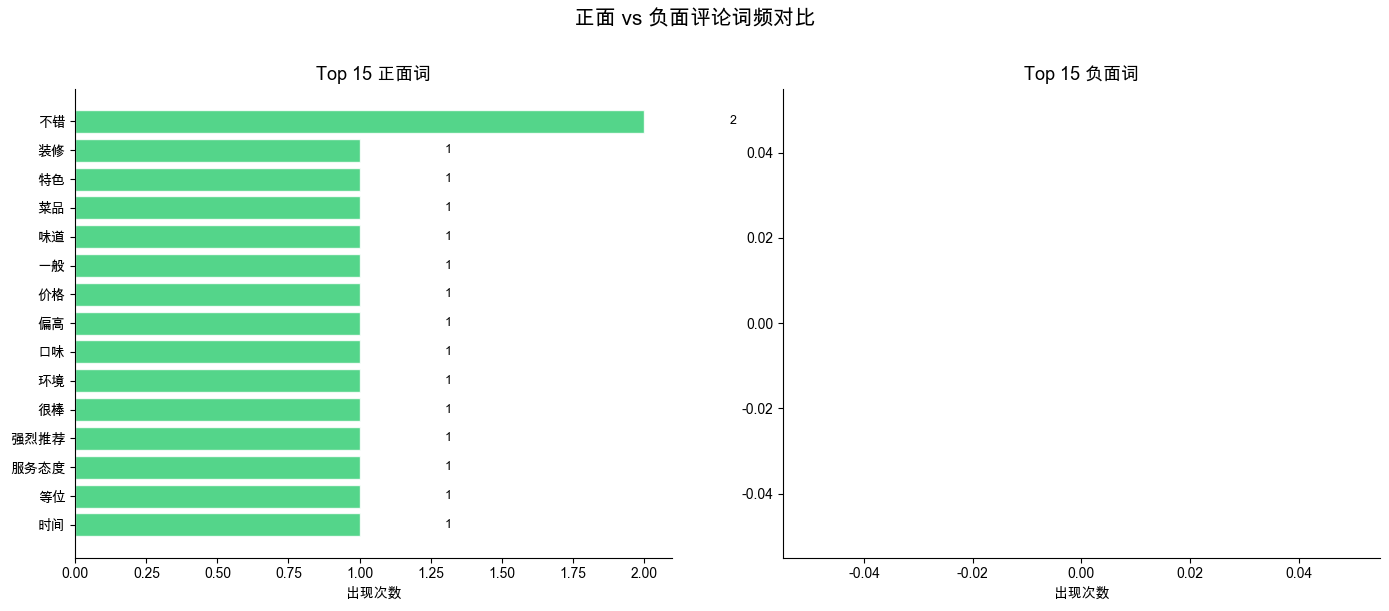

In [10]:
# ── 分组词频与痛点词分析 ──
pos_words, neg_words = [], []
for _, row in df.iterrows():
    words = tokenize(row['text'])
    if row['sentiment_label'] == '正面':
        pos_words.extend(words)
    elif row['sentiment_label'] == '负面':
        neg_words.extend(words)

pos_freq = Counter(pos_words)
neg_freq = Counter(neg_words)

# 痛点词：负面/正面频率比最高
MIN_COUNT = 5
pain_ratio = {w: neg_freq[w] / max(pos_freq[w], 1)
              for w in neg_freq if neg_freq[w] >= MIN_COUNT}
pain_points = sorted(pain_ratio.items(), key=lambda x: -x[1])[:15]

print("【痛点词 Top 15（负面/正面频率比）】")
print(f"{'词':10s} {'负面':>6s} {'正面':>6s} {'比率':>6s}")
print("-" * 35)
for word, ratio in pain_points:
    print(f"{word:10s} {neg_freq[word]:6d} {pos_freq[word]:6d} {ratio:5.1f}x")

# ── 可视化 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_freq_bar(ax, freq_counter, title, color, n=15):
    top = freq_counter.most_common(n)
    words_list = [w for w, _ in reversed(top)]
    counts = [c for _, c in reversed(top)]
    bars = ax.barh(words_list, counts, color=color, alpha=0.82, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('出现次数')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_freq_bar(axes[0], pos_freq, 'Top 15 正面词', '#2ECC71')
plot_freq_bar(axes[1], neg_freq, 'Top 15 负面词', '#E74C3C')
plt.suptitle('正面 vs 负面评论词频对比', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('word_freq_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

::: {.callout-warning}
## ⚠️ 词频分析的局限性

词频只告诉你「什么词出现得多」，不能告诉你「这些词在什么语境下出现」。

「排队」高频，是消费者喜欢排队吗？还是在抱怨等位太久？

要回答这类问题，需要进入 Step 4 的主题分析。
:::

---

## Step 4  主题分析

> *让机器归纳消费者在谈论什么*

---

### 4.1  从词频到主题

词频是「术语层」，主题是「议题层」。

「装修」「灯光」「座位」这三个词背后共同指向「环境」这个议题。
**LDA（Latent Dirichlet Allocation）** 能自动发现这种潜在结构。

### 4.2  LDA 的直觉（不推导公式）

| LDA 的假设 | 含义 |
|-----------|------|
| 每篇文档 = 多个主题的混合 | 一条评论可以 70% 谈环境、30% 谈口味 |
| 每个主题 = 词的概率分布 | 「环境」主题下，「装修」「灯光」出现概率高 |
| 主题数 K 由分析者指定 | 需要通过实验和业务判断来选择 |
| 输出：词-主题矩阵 | 每个主题由最高概率的词来描述 |

::: {.callout-note}
## 给有统计背景的学生

LDA 是贝叶斯生成模型：先从 Dir(α) 抽主题分布 θ，再对每个词从 Dir(β) 抽词分布 φ，最后生成词。
参数用变分 EM 估计。感兴趣可阅读 Blei et al. (2003) JMLR 原文。
:::

::: {.callout-tip}
## 💬 提示词参考

> 我的 DataFrame 中 text 列是中文评论（原始文字，还未分词）。请帮我用 scikit-learn 做 LDA 主题建模：  
> 1. 用 CountVectorizer 构建文档-词矩阵，分词用 jieba，保留至少出现在 3 条文档中、且不超过 85% 文档中的词，最多 2000 个特征词；
> 2. 训练 K=6 的 LDA 模型；   
> 3. 打印每个主题的 Top 10 词；   
> 4. 为每条评论分配主导主题（概率最高的那个）；   
> 5. 计算各主题的平均星级并排序。

**关键超参数说明（提示词中应明确）：**

- `min_df=3`：过滤低频词，减少噪音（数据量大时可改为 5 或 10）
- `max_df=0.85`：过滤出现在 85% 以上文档中的词（停用词的漏网之鱼）
- `K=6`：主题数——**这是你需要调整的超参数**

💡 **调参技巧**：先用 K=4、6、8 分别运行，哪个 K 的主题词最容易命名，就选哪个。主观判断在这里是合理的。
:::

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

# Step 1：向量化
vectorizer = CountVectorizer(
    tokenizer=tokenize,
    max_features=2000,
    min_df=3,
    max_df=0.85,
)
dtm = vectorizer.fit_transform(df['text'])
vocab = vectorizer.get_feature_names_out()
print(f"文档-词矩阵：{dtm.shape[0]} 篇评论  x  {dtm.shape[1]} 个词")

# Step 2：训练 LDA（修改 K 值后重新运行）
K = 6
lda = LatentDirichletAllocation(n_components=K, random_state=42, max_iter=30)
lda.fit(dtm)

# Step 3：打印主题词
print(f"【LDA 主题结果（K={K}）】")
print("请根据词的语义为每个主题命名，填写到下方 TOPIC_NAMES 字典中")
print("-" * 55)
for i, topic in enumerate(lda.components_):
    top_words = [vocab[j] for j in topic.argsort()[:-11:-1]]
    print(f"主题 {i+1}：{'  |  '.join(top_words)}")
    print(f"  → 你的命名：____________________")

ValueError: After pruning, no terms remain. Try a lower min_df or a higher max_df.

In [14]:
# Step 4：分配主导主题 + Step 5：主题-星级交叉分析

doc_topic = lda.transform(dtm)
df['dominant_topic'] = doc_topic.argmax(axis=1)
df['topic_confidence'] = doc_topic.max(axis=1)

# ── 在运行上方代码并命名主题后，修改此字典 ──
TOPIC_NAMES = {
    0: '主题1（待命名）',
    1: '主题2（待命名）',
    2: '主题3（待命名）',
    3: '主题4（待命名）',
    4: '主题5（待命名）',
    5: '主题6（待命名）',
}
# 参考命名示例（实际结果可能不同）：
# 0: '用餐环境', 1: '服务体验', 2: '菜品口味',
# 3: '价格性价比', 4: '地理位置', 5: '用餐场合'

df['topic_label'] = df['dominant_topic'].map(TOPIC_NAMES)

topic_stats = (df.groupby('topic_label')['stars']
               .agg(['mean', 'count'])
               .rename(columns={'mean': '平均星级', 'count': '评论数'})
               .sort_values('平均星级'))
print("【各主题平均星级（升序，最低的是核心痛点）】")
print(topic_stats.round(2))

NameError: name 'lda' is not defined

::: {.callout-important}
## 📌 主题命名：人的判断不可省略

LDA 的输出是词的列表，**主题命名是分析者主动解释数据的过程**，不是算法给出的。

不同分析者对同一组词可能命名不同，应在报告中记录命名理由。

**操作步骤**：
1. 读完主题词后，在 `TOPIC_NAMES` 字典里填入你的命名
2. 重新运行后续所有代码，图表标签会自动更新
:::

### 4.3  课堂练习：K 值的选择

修改 `K = 3 / 5 / 8 / 12`，重新运行 LDA，观察主题词变化。
从「业务可解释性」和「主题间区分度」两个维度，推荐一个 K 值并说明理由。
思考：是否存在一个客观正确的 K 值？

---

## Step 5  情感分析

> *理解消费者对各议题的评价情绪*

---

### 5.1  两种方法对比

| 方法 | 原理 | 优点 | 局限 |
|------|------|------|------|
| 词典法 | 匹配情感词典，累加极性分数 | 无需训练数据；可解释 | 依赖词典质量；难处理反语 |
| 监督学习 | 用星级标签训练分类模型 | 准确率更高；能学语境 | 需要标注数据（stars 正好满足） |

**大众点评数据的核心优势再次体现**：`stars` 是天然标签，直接用于监督学习。

::: {.callout-tip}
## 💬 提示词参考

> 我有一个餐厅评论 DataFrame，text 列是评论文字，stars 列是 1-5 星评分。请帮我做如下分析：
> (1) 将 4-5 星标记为正面（label=1），1-2 星标记为负面（label=0），去掉 3 星；   
> (2) 用 TF-IDF 向量化评论文本（max_features=5000）；   
> (3) 按 80/20 划分训练集和测试集（设 random_state=42，用 stratify 保持类别比例）；   
> (4) 训练逻辑回归分类器；   
> (5) 打印测试集准确率和 classification_report；   
> (6) 可视化混淆矩阵；   
> (7) 列出系数最大的正面词和负面词各 12 个，画水平条形图。

**为什么选逻辑回归？**

- **可解释性强**：可直接查看每个词对正/负面预测的权重（系数）
- **训练速度快**：适合课堂演示，秒级完成
- **基准表现好**：文本分类任务中往往接近复杂模型

提示词中的第 (7) 步「列出最重要的词」，迫使 AI 生成展示模型可解释性的代码——这比只看准确率更有教学价值，也能帮助你发现模型是否学到了合理的语义特征。
:::

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 1：准备标注数据
df_clf = df[df['stars'].isin([1, 2, 4, 5])].copy()
df_clf['label'] = (df_clf['stars'] >= 4).astype(int)
print(f"训练数据：{len(df_clf)} 条")
print(f"  正面（4-5星）：{df_clf['label'].sum()} 条 ({df_clf['label'].mean():.0%})")
print(f"  负面（1-2星）：{(df_clf['label']==0).sum()} 条 ({1-df_clf['label'].mean():.0%})")

# Step 2-4：TF-IDF + 逻辑回归
vectorizer_clf = TfidfVectorizer(tokenizer=tokenize, max_features=5000, sublinear_tf=True)
X = vectorizer_clf.fit_transform(df_clf['text'])
y = df_clf['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
print(f"测试集准确率：{clf.score(X_test, y_test):.2%}")
print()
print(classification_report(y_test, clf.predict(X_test), target_names=['负面','正面']))

训练数据：5 条
  正面（4-5星）：5 条 (100%)
  负面（1-2星）：0 条 (0%)


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

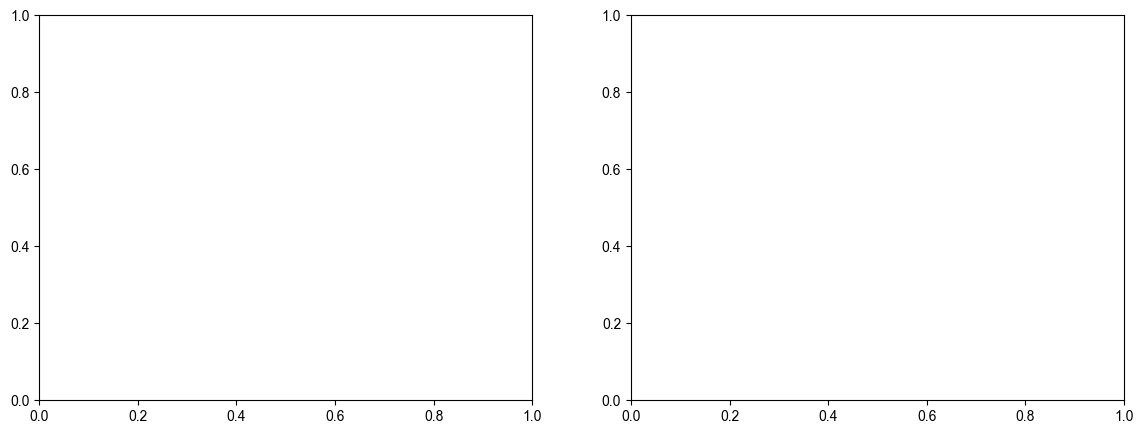

In [17]:
# ── 可视化：混淆矩阵 + 情感极性词 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 混淆矩阵
cm = confusion_matrix(y_test, clf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['预测负面','预测正面'],
            yticklabels=['实际负面','实际正面'], ax=axes[0])
axes[0].set_title('混淆矩阵', fontsize=13, fontweight='bold')

# 情感极性词（模型系数）
feat_names = vectorizer_clf.get_feature_names_out()
coefs = clf.coef_[0]
n_show = 12
pos_idx = coefs.argsort()[-n_show:][::-1]
neg_idx = coefs.argsort()[:n_show]
all_items = [(feat_names[i], coefs[i]) for i in neg_idx[::-1]] +             [(feat_names[i], coefs[i]) for i in pos_idx]
words_show = [w for w, _ in all_items]
coefs_show = [c for _, c in all_items]
colors = ['#E74C3C' if c < 0 else '#2ECC71' for c in coefs_show]

axes[1].barh(words_show, coefs_show, color=colors, alpha=0.82)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('情感极性词（逻辑回归系数）', fontsize=13, fontweight='bold')
axes[1].set_xlabel('← 负面倾向         正面倾向 →')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('sentiment_model.png', dpi=150, bbox_inches='tight')
plt.show()

::: {.callout-caution}
## ⚠️ 情感分析的常见陷阱：粒度不匹配

整篇评论可能是正面的（打了 4 星），但其中某个句子在批评服务。

更精细的分析需要**方面级情感分析（Aspect-Based Sentiment Analysis）**：对「口味」「服务」「环境」分别打分。这是大型语言模型特别擅长的任务。

**进阶挑战**：写一段提示词，让 Claude 对一条评论提取各方面的情感评分，输出为 JSON 格式。
:::

---

## Step 6  可视化与决策建议

> *将数据洞察转化为可行建议*

---

### 6.1  可视化原则：为决策者服务

好的可视化应当：
- **一眼看出核心结论**（不要让读者自己算）
- **注释说明数据来源和局限性**
- **避免误导性设计**（如截断纵轴夸大差异）

::: {.callout-tip}
## 💬 提示词参考

> 我有一个餐厅评论 DataFrame，包含 stars（整数1-5）、topic_label（字符串）、sentiment_label（正面/中性/负面）、date（YYYY-MM-DD 格式字符串）、price_per_person（浮点数）。请用 matplotlib 制作一个 2x2 的综合仪表盘：左上是星级分布柱状图（不同星级不同颜色），右上是各主题的正/中/负面评论占比热力图，左下是按月聚合的平均星级折线图（带均值参考线），右下是人均消费 5 个区间与平均星级的柱状图。整体标题「餐厅口碑综合分析仪表盘」，字体 SimHei。

**仪表盘提示词的关键要素：**

1. **列举所有用到的字段名和数据类型**，避免 AI 猜测
2. **明确图表布局**（2×2，不是「几张图」）
3. **为每张子图指定图表类型和核心要素**
4. **提出格式要求**（中文字体），避免乱码

💡 你可以修改这段提示词，把「2x2」改成「1x4」或「3x2」，或者要求加入地图、气泡图等其他形式。
:::

KeyError: 'topic_label'

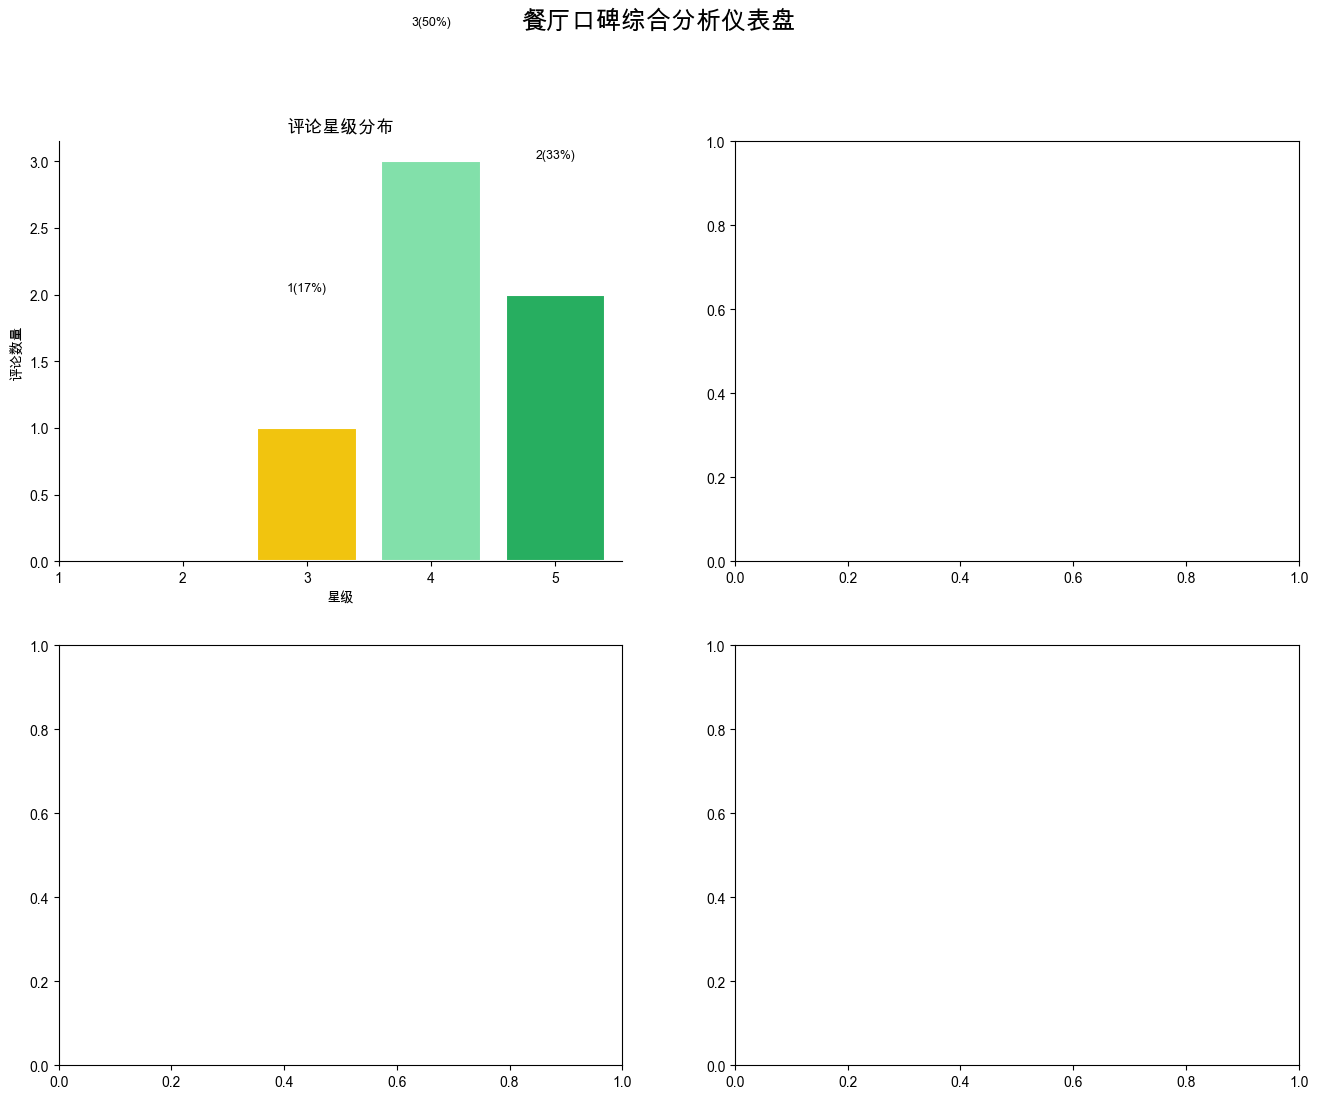

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('餐厅口碑综合分析仪表盘', fontsize=18, fontweight='bold', y=0.99)

STAR_COLORS = {1:'#C0392B', 2:'#E67E22', 3:'#F1C40F', 4:'#82E0AA', 5:'#27AE60'}

# ── 图① 星级分布 ──
ax = axes[0, 0]
star_counts = df['stars'].value_counts().sort_index()
bars = ax.bar(star_counts.index, star_counts.values,
              color=[STAR_COLORS[s] for s in star_counts.index], edgecolor='white', lw=1.5)
for bar, cnt in zip(bars, star_counts.values):
    pct = cnt / len(df) * 100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{cnt}({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('评论星级分布', fontsize=13, fontweight='bold')
ax.set_xlabel('星级'); ax.set_ylabel('评论数量')
ax.set_xticks([1,2,3,4,5])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── 图② 主题-情感热力图 ──
ax = axes[0, 1]
pivot = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)
for col in ['正面', '中性', '负面']:
    if col not in pivot.columns: pivot[col] = 0
pivot_pct = pivot[['正面', '中性', '负面']].div(pivot.sum(axis=1), axis=0)
im = ax.imshow(pivot_pct.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(['正面','中性','负面'])
ax.set_yticks(range(len(pivot_pct))); ax.set_yticklabels(pivot_pct.index, fontsize=9)
ax.set_title('各主题情感分布', fontsize=13, fontweight='bold')
for i in range(len(pivot_pct)):
    for j in range(3):
        v = pivot_pct.values[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9,
                color='black' if 0.25 < v < 0.75 else 'white')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── 图③ 月度趋势 ──
ax = axes[1, 0]
df['date_p'] = pd.to_datetime(df['date'], errors='coerce')
monthly = df.groupby(df['date_p'].dt.to_period('M'))['stars'].mean()
months_str = [str(m) for m in monthly.index]
ax.plot(months_str, monthly.values, marker='o', lw=2, color='#2E75B6', ms=5)
mean_val = monthly.mean()
ax.axhline(mean_val, color='gray', linestyle='--', alpha=0.6, label=f'均值 {mean_val:.2f}')
ax.fill_between(months_str, monthly.values, mean_val,
                where=monthly.values>=mean_val, alpha=0.15, color='green')
ax.fill_between(months_str, monthly.values, mean_val,
                where=monthly.values<mean_val, alpha=0.15, color='red')
ax.set_title('月均星级趋势', fontsize=13, fontweight='bold')
ax.set_ylabel('平均星级'); ax.set_ylim(1, 5)
ax.legend(fontsize=9)
step = max(1, len(months_str)//6)
ax.set_xticks(range(0, len(months_str), step))
ax.set_xticklabels(months_str[::step], rotation=30, ha='right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── 图④ 价格带-满意度 ──
ax = axes[1, 1]
bins = [0, 50, 100, 150, 200, 800]
labels_p = ['<50', '50-100', '100-150', '150-200', '>200']
price_sat = (df[df['price_per_person'].notna()]
             .assign(pb=lambda x: pd.cut(x['price_per_person'], bins=bins, labels=labels_p))
             .groupby('pb', observed=True)['stars']
             .agg(['mean','count']))
colors_p = ['#5DADE2','#48C9B0','#F4D03F','#E59866','#EC7063']
for i, (idx, row) in enumerate(price_sat.iterrows()):
    bar = ax.bar(i, row['mean'], color=colors_p[i], alpha=0.85, edgecolor='white')
    ax.text(i, row['mean']+0.05, f"{row['mean']:.2f}(n={int(row['count'])})",
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(price_sat))); ax.set_xticklabels(price_sat.index)
ax.set_title('人均消费区间 vs 平均星级', fontsize=13, fontweight='bold')
ax.set_ylabel('平均星级'); ax.set_ylim(1, 5.5)
ax.axhline(df['stars'].mean(), color='gray', linestyle='--', alpha=0.6,
           label=f'总体均值 {df["stars"].mean():.2f}')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('restaurant_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2  从图表到决策建议

| 分析维度 | 数据发现（根据你的结果填写） | 决策建议 |
|---------|---------------------------|---------|
| 整体口碑 | 4星及以上占 ___% | — |
| 核心痛点 | 「___」主题负面率最高 | 优先改善该维度 |
| 口碑驱动词 | 「___」主导正面评论 | 在营销中放大这些优势 |
| 价格敏感度 | ___元区间满意度最高 | 调价策略参考 |
| 时序趋势 | （节假日效应？季节性？） | — |

::: {.callout-warning}
## ⚠️ 分析局限性（必须在报告中说明）

1. **选择性偏差**：只有愿意写评论的人才留下数据，非常满意和非常不满意的人更倾向于写
2. **评论数量 ≠ 客流量**：高评论量可能只反映用户活跃度
3. **刷单风险**：部分正面评论可能是商家购买的，负面评论可能是竞争对手所为
4. **平台覆盖率差异**：大众点评用户在城市、年龄层分布不均，不代表全人群

学术诚信要求：这些偏差的方向和程度应当在结论章节明确说明。
:::

---

# 附录 A：环境配置

```bash
conda create -n dianping python=3.10
conda activate dianping
pip install pandas numpy matplotlib seaborn
pip install jieba wordcloud snownlp
pip install scikit-learn
pip install requests beautifulsoup4
```

# 附录 B：教学数据集来源

| 数据来源 | 说明 | 推荐用途 |
|---------|------|---------|
| 天池公开数据集 | 阿里天池平台，多个餐饮评论数据集 | Step 2-6 |
| Kaggle Chinese NLP | 多个中文情感分析标准数据集 | Step 5 对比 |
| ChnSentiCorp | 7000 条酒店/电脑评论，带正负标签 | Step 5 监督学习 |

# 附录 C：期末大作业选题

- **竞品分析**：同城同品类三家餐厅，对比评论主题分布和情感结构
- **政策评估**：餐饮卫生整改前后口碑变化（双重差分思路）
- **价格带研究**：不同人均消费区间消费者关注点差异
- **LLM 辅助标注**：设计提示词，让 Claude/GPT 做方面级情感标注，与监督学习对比

# 附录 D：参考文献

1. Blei, D.M., Ng, A.Y., Jordan, M.I. (2003). Latent Dirichlet Allocation. *JMLR*, 3, 993-1022.
2. Hu, M., Liu, B. (2004). Mining and summarizing customer reviews. *KDD*.
3. 刘兵 (2012). 情感分析：挖掘观点、情感和情绪. 机械工业出版社.